# Task 002 - Data Preparation

## CRISP-DM Phase 3

---

# مقدمه

در تسک قبلی شما مرحله **Data Understanding** را روی دیتاست بیماری قلبی انجام دادید.

در پایان آن مرحله باید به درک مناسبی از موارد زیر رسیده باشید:

* ساختار داده
* کیفیت داده
* ویژگی‌های مهم
* ارتباط ویژگی‌ها با متغیر هدف
* مشکلات موجود در داده
* مناسب بودن داده برای مدل‌سازی

اکنون وارد مرحله سوم فرآیند CRISP-DM یعنی **Data Preparation** می‌شویم.

---

# یادآوری چالش کسب‌وکار

شما به عنوان تحلیلگر داده در یک مرکز درمانی قلب و عروق فعالیت می‌کنید.

هدف کسب‌وکار:

تشخیص احتمال ابتلا به بیماری قلبی بر اساس ویژگی‌های بیماران.

متغیر هدف:

```python
target
```

* 0 → Healthy
* 1 → Heart Disease

---

# نوع مسئله داده‌کاوی

با توجه به تحلیل مرحله قبل:

متغیر هدف مشخص است و دو کلاس دارد.

بنابراین مسئله اصلی:

## Supervised Learning

و به طور دقیق‌تر:

## Binary Classification

---

# الگوریتم‌های احتمالی آینده

در مراحل بعدی ممکن است از الگوریتم‌های زیر استفاده شود:

* Logistic Regression
* Decision Tree
* Random Forest
* KNN
* SVM
* Naive Bayes

بنابراین باید داده را به شکلی آماده کنیم که برای این الگوریتم‌ها مناسب باشد.

---

# هدف این تسک

ایجاد یک دیتاست نهایی و آماده برای مرحله Modeling

---

# خروجی نهایی مورد انتظار

در پایان این تسک باید فایل زیر را ایجاد کنید:

```python
heart_prepared.csv
```

این فایل باید:

* تمیز باشد
* ویژگی‌های انتخاب شده را داشته باشد
* ویژگی‌های جدید مورد نیاز را داشته باشد
* فرمت مناسبی داشته باشد
* داده‌های عددی مقیاس‌بندی شده باشند
* برای مدل‌سازی آماده باشد

---

# قوانین

- استفاده از Scikit-Learn ممنوع
- استفاده از AutoML ممنوع


فقط از موارد زیر استفاده شود

- NumPy
- Pandas
- Matplotlib
- Seaborn

---

In [51]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [52]:
df = pd.read_csv("heart.csv")

# بخش اول

# Data Selection

---

## سوال 1

براساس تحلیل مرحله قبل:

کدام ستون‌ها بیشترین ارتباط را با target داشتند؟

فهرست آن‌ها را استخراج کنید.

---

In [53]:
corr = df.corr()
corr["target"].abs().sort_values(ascending=False)

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64

## سوال 2

یک جدول تهیه کنید:

| Feature | Business Importance | Data Importance |
| ------- | ------------------- | --------------- |

---

In [54]:
corr = df.corr(numeric_only=True)["target"]

def data_importance(correlation):
    correlation = abs(correlation)
    if correlation >= 0.5:
        return "High"
    elif correlation >= 0.3:
        return "Medium"
    else:
        return "Low"

business_importance = {
    "age": "High",
    "sex": "Medium",
    "cp": "High",
    "trestbps": "Medium",
    "chol": "Medium",
    "fbs": "Low",
    "restecg": "Medium",
    "thalach": "High",
    "exang": "High",
    "oldpeak": "High",
    "slope": "High",
    "ca": "High",
    "thal": "High"
}
table = pd.DataFrame({
    "Feature": corr.index.drop("target"),
    "Business Importance": [business_importance[col] for col in corr.index.drop("target")],
    "Data Importance": [data_importance(corr[col]) for col in corr.index.drop("target")]
})

print(table)

     Feature Business Importance Data Importance
0        age                High             Low
1        sex              Medium             Low
2         cp                High          Medium
3   trestbps              Medium             Low
4       chol              Medium             Low
5        fbs                 Low             Low
6    restecg              Medium             Low
7    thalach                High          Medium
8      exang                High          Medium
9    oldpeak                High          Medium
10     slope                High          Medium
11        ca                High          Medium
12      thal                High          Medium


## سوال 3

حداقل سه ویژگی را انتخاب کنید که احتمال می‌دهید برای مدل‌سازی مفید نباشند.

دلایل خود را بنویسید.

---

## سوال 4

یک نسخه جدید از دیتاست بسازید که فقط شامل ویژگی‌های منتخب شما باشد.

نام:

```python
selected_df
```

---

In [55]:
selected_df = df.drop(columns = ["chol" ,"fbs", "ca"])

## سوال 5

تعداد ویژگی‌ها قبل و بعد از Selection را مقایسه کنید.

---

In [56]:
print(selected_df.columns)
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope', 'thal', 'target'],
      dtype='str')
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')


# بخش دوم

# Data Cleaning

---

## سوال 6

تمام مقادیر Null را مجدداً بررسی کنید.

---

In [57]:
for index in df.columns:
    print(f"{index} {df[index].isna().sum()}")

age 0
sex 0
cp 0
trestbps 0
chol 0
fbs 0
restecg 0
thalach 0
exang 0
oldpeak 0
slope 0
ca 0
thal 0
target 0


## سوال 7

برای هر ستون مشخص کنید:

* تعداد Null
* درصد Null

---

In [58]:
for index in df.columns:
    null_count = df[index].isna().sum()
    null_percent = (null_count / len(df)) * 100

    print(f"{index} : {null_count},  {null_percent:.2f}%")

age : 0,  0.00%
sex : 0,  0.00%
cp : 0,  0.00%
trestbps : 0,  0.00%
chol : 0,  0.00%
fbs : 0,  0.00%
restecg : 0,  0.00%
thalach : 0,  0.00%
exang : 0,  0.00%
oldpeak : 0,  0.00%
slope : 0,  0.00%
ca : 0,  0.00%
thal : 0,  0.00%
target : 0,  0.00%


## سوال 8

اگر داده گمشده وجود دارد:

سه روش مختلف برای پر کردن آن پیشنهاد دهید.

---

## سوال 9

یکی از روش‌ها را انتخاب کرده و پیاده‌سازی کنید.

---

## سوال 10

رکوردهای تکراری را شناسایی کنید.

---

In [59]:
df.loc[df.duplicated(keep = False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


## سوال 11

نسخه‌ای از داده بدون رکوردهای تکراری ایجاد کنید.

---

In [60]:
df.drop(index=164)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## سوال 12

با استفاده از Boxplot و IQR:

Outlier های هر ویژگی عددی را پیدا کنید.

---

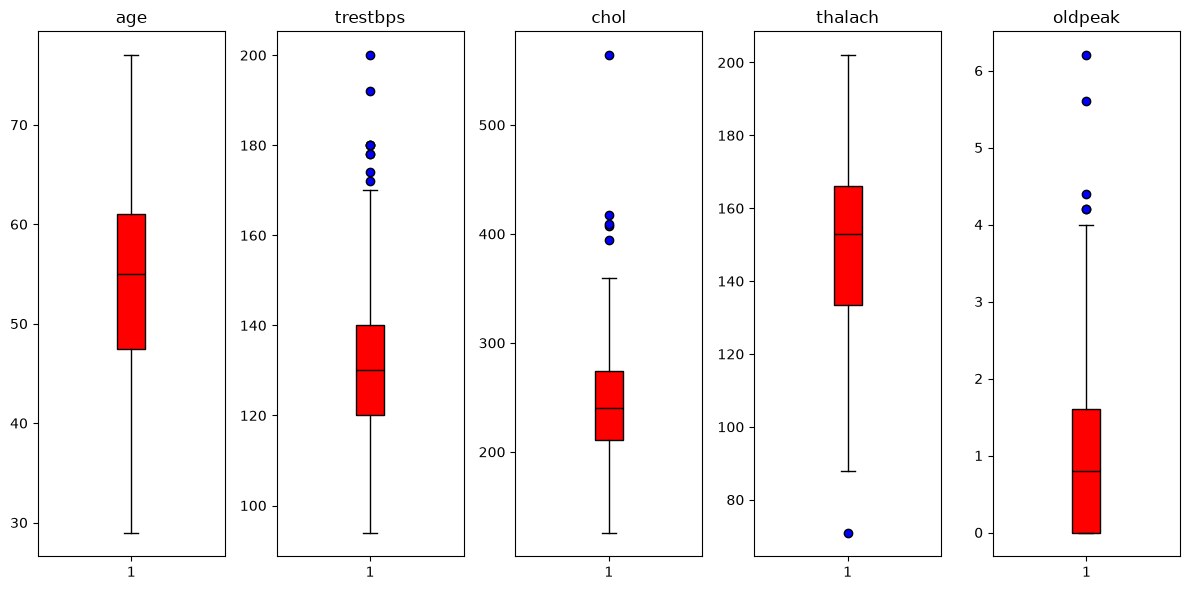

In [61]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col.append(index)
fig , ax = plt.subplots(figsize=(12,6),ncols=len(col))
for i ,column in enumerate(col):
    ax[i].boxplot(df[column],patch_artist=True,boxprops={"facecolor":"red"},medianprops={"color":"black"},flierprops={"markerfacecolor":"blue"})
    ax[i].set_title(column)
plt.tight_layout()

In [62]:
for index in df[col]:
    Q1 = df[index].quantile(0.25)
    Q3 = df[index].quantile(0.75)
    IQR = Q3-Q1
    outlier = df[(df[index]> Q3 + (IQR * 1.5)) | (df[index] < Q1 - (IQR * 1.5))] 
outlier


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
101,59,1,3,178,270,0,0,145,0,4.2,0,0,3,1
204,62,0,0,160,164,0,0,145,0,6.2,0,3,3,0
221,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
250,51,1,0,140,298,0,1,122,1,4.2,1,3,3,0
291,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0


## سوال 13

جدولی ایجاد کنید:

| Feature | Number of Outliers |

---

## سوال 14

برای Outlier ها سه استراتژی مختلف پیشنهاد دهید.

---

## سوال 15

یک استراتژی را انتخاب و پیاده‌سازی کنید.

---

# بخش سوم

# Data Construction

---

در این بخش باید ویژگی‌های جدید ایجاد شوند.

---

## سوال 16

سن را به سه گروه تقسیم کنید:

* Young
* Middle Age
* Senior

ستون جدید:

```python
age_group
```

---

In [63]:
bins = [0, 44, 64, float('inf')]
labels = ["Young", "Middle Age", "Senior"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df[["age", "age_group"]].head())

   age   age_group
0   63  Middle Age
1   37       Young
2   41       Young
3   56  Middle Age
4   57  Middle Age


## سوال 17

برای chol سطح ریسک ایجاد کنید:

* Low
* Normal
* High

---

In [64]:
bins = [0, 199, 239, float('inf')]
labels = ["Low", "Normal", "High"]

df["chol_risk"] = pd.cut(
    df["chol"],
    bins=bins,
    labels=labels,
    include_lowest=True)

print(df[["chol", "chol_risk"]].head())

   chol chol_risk
0   233    Normal
1   250      High
2   204    Normal
3   236    Normal
4   354      High


## سوال 18

برای trestbps سطح فشار خون تعریف کنید.

---

In [65]:
bins = [0, 89, 120, float('inf')]
labels = ["Low", "Normal", "High"]

df["bp_level"] = pd.cut(
    df["trestbps"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df[["trestbps", "bp_level"]].head())

   trestbps bp_level
0       145     High
1       130     High
2       130     High
3       120   Normal
4       120   Normal


## سوال 19

حداقل دو Feature جدید طراحی کنید.

دلایل کسب‌وکاری آن را توضیح دهید.

---

In [66]:
df["heart_rate_ratio"] = df["thalach"] / df["age"]

print(df[["age", "thalach", "heart_rate_ratio"]].head())

   age  thalach  heart_rate_ratio
0   63      150          2.380952
1   37      187          5.054054
2   41      172          4.195122
3   56      178          3.178571
4   57      163          2.859649


این ویژگی نسبت حداکثر ضربان قلب به سن را نشان می‌دهد

.دلیل کسب‌وکاری : افراد جوان‌تر معمولاً حداکثر ضربان قلب بیشتری دارند

In [67]:
df["cardio_risk_score"] = df["trestbps"] + df["chol"]

print(df[["trestbps", "chol", "cardio_risk_score"]].head())

   trestbps  chol  cardio_risk_score
0       145   233                378
1       130   250                380
2       130   204                334
3       120   236                356
4       120   354                474


ترکیب فشار خون و کلسترول برای ایجاد یک شاخص ریسک
 
 دلیل کسب‌وکاری:فشار خون بالا و کلسترول بالا دو عامل اصلی خطر بیماری‌های قلبی هستند ترکیب آن‌ها می‌تواند ریسک کلی بیمار را بهتر نشان دهد

## سوال 20

جدول زیر را تکمیل کنید:

| New Feature | Business Reason |

---

In [68]:
new_features = pd.DataFrame({
    "New Feature": ["heart_rate_ratio", "cardio_risk_score"],
    "Business Reason": [
        "Shows heart performance relative to age.",
        "Combines blood pressure and cholesterol to estimate cardiovascular risk."
    ]
})

print(new_features)

         New Feature                                    Business Reason
0   heart_rate_ratio           Shows heart performance relative to age.
1  cardio_risk_score  Combines blood pressure and cholesterol to est...


| New Feature                               | Business Reason                                                                                                                                                                                 |
| ----------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **heart_rate_ratio** (`thalach / age`)    | این ویژگی عملکرد قلب را نسبت به سن بیمار نشان می‌دهد. از آنجا که حداکثر ضربان قلب با افزایش سن کاهش می‌یابد، این نسبت می‌تواند شاخص دقیق‌تری برای ارزیابی وضعیت قلب و تشخیص بیماران پرخطر باشد. |
| **cardio_risk_score** (`trestbps + chol`) | این ویژگی فشار خون و کلسترول را که هر دو از عوامل اصلی خطر بیماری‌های قلبی هستند، در یک شاخص ترکیب می‌کند و به شناسایی بیماران با ریسک بالاتر کمک می‌کند.                                       |


# بخش چهارم

# Data Integration

---

فرض کنید داده جدیدی از آزمایشگاه دریافت شده است.

فایل فرضی:

```python
lab_results.csv
```

---

## سوال 21

یک DataFrame آزمایشی بسازید.

---

In [69]:
lab_results = pd.DataFrame({
    "patient_id": [1, 2, 3, 4, 5],
    "blood_sugar": [95, 140, 110, 125, 100],
    "hemoglobin": [14.2, 13.5, 15.1, 12.8, 14.7],
    "creatinine": [0.9, 1.2, 1.0, 1.3, 0.8]
})

print(lab_results)

   patient_id  blood_sugar  hemoglobin  creatinine
0           1           95        14.2         0.9
1           2          140        13.5         1.2
2           3          110        15.1         1.0
3           4          125        12.8         1.3
4           5          100        14.7         0.8


## سوال 22

یک کلید مشترک تعریف کنید.

---

In [70]:
heart_df = pd.read_csv("heart.csv")

heart_df["patient_id"] = range(1, len(heart_df) + 1)

print(heart_df[["patient_id"]].head())

   patient_id
0           1
1           2
2           3
3           4
4           5


In [71]:
lab_results = pd.DataFrame({
    "patient_id": [1, 2, 3, 4, 5],
    "blood_sugar": [95, 140, 110, 125, 100],
    "hemoglobin": [14.2, 13.5, 15.1, 12.8, 14.7],
    "creatinine": [0.9, 1.2, 1.0, 1.3, 0.8]
})

print(lab_results)

   patient_id  blood_sugar  hemoglobin  creatinine
0           1           95        14.2         0.9
1           2          140        13.5         1.2
2           3          110        15.1         1.0
3           4          125        12.8         1.3
4           5          100        14.7         0.8


## سوال 23

Merge را انجام دهید.

---

In [72]:
merged_df = pd.merge(heart_df, lab_results, on="patient_id", how="left")

print(merged_df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  patient_id  blood_sugar  hemoglobin  creatinine  
0   0     1       1           1         95.0        14.2         0.9  
1   0     2       1           2        140.0        13.5         1.2  
2   0     2       1           3        110.0        15.1         1.0  
3   0     2       1           4        125.0        12.8         1.3  
4   0     2       1           5        100.0        14.7         0.8  


## سوال 24

انواع Merge زیر را مقایسه کنید:

* inner
* left
* right
* outer

---

In [73]:
merged_df = pd.merge(heart_df, lab_results, on="patient_id", how="inner")

print(merged_df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  patient_id  blood_sugar  hemoglobin  creatinine  
0   0     1       1           1           95        14.2         0.9  
1   0     2       1           2          140        13.5         1.2  
2   0     2       1           3          110        15.1         1.0  
3   0     2       1           4          125        12.8         1.3  
4   0     2       1           5          100        14.7         0.8  


faghat record hayi ro negah midare ke kelide moshtarak (patient_id) dar hardo DataFrame vojod dashte bashad

In [74]:
merged_df = pd.merge(heart_df, lab_results, on="patient_id", how="left")

print(merged_df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  patient_id  blood_sugar  hemoglobin  creatinine  
0   0     1       1           1         95.0        14.2         0.9  
1   0     2       1           2        140.0        13.5         1.2  
2   0     2       1           3        110.0        15.1         1.0  
3   0     2       1           4        125.0        12.8         1.3  
4   0     2       1           5        100.0        14.7         0.8  


tamame rokord haye DataFrame samte chap (heart_df) hefz mishavand va dar soorate vojod etelaate DataFrame samte rast ezafe mishavad

In [75]:
merged_df = pd.merge(heart_df, lab_results, on="patient_id", how="right")

print(merged_df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  patient_id  blood_sugar  hemoglobin  creatinine  
0   0     1       1           1           95        14.2         0.9  
1   0     2       1           2          140        13.5         1.2  
2   0     2       1           3          110        15.1         1.0  
3   0     2       1           4          125        12.8         1.3  
4   0     2       1           5          100        14.7         0.8  


tamame DataFrame samte rast (lab_resault) hefz mishavand va etelaate DataFrame samte chap dar soorate vojod ezafe mishavad

In [76]:
merged_df = pd.merge(heart_df, lab_results, on="patient_id", how="outer")

print(merged_df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  patient_id  blood_sugar  hemoglobin  creatinine  
0   0     1       1           1         95.0        14.2         0.9  
1   0     2       1           2        140.0        13.5         1.2  
2   0     2       1           3        110.0        15.1         1.0  
3   0     2       1           4        125.0        12.8         1.3  
4   0     2       1           5        100.0        14.7         0.8  


tamame record haye hardo DataFrame ra negah midarad

## سوال 25

مشخص کنید برای این پروژه کدام نوع Merge مناسب‌تر است.

---

In [77]:
merged_df = pd.merge(
    heart_df,
    lab_results,
    on="patient_id",
    how="left"
)

left behtar ast chon file asli heart_df ast ke shamele etelaate bimaran ast va file lab_resault faghat etelaate takmili azmayeshgah ra darad pas bayad hameye bimaran mojood dar heart_csv hefz shavand va agar baraye bimari natijeye azmayesh vojod dasht be etelaate aan ezafe shavad va agar natije azmayesh mojod nabod maghadire aan be soorate NaN sabt shavad

# بخش پنجم

# Data Formatting

---

## سوال 26

نوع داده تمامی ستون‌ها را بررسی کنید.

---

In [78]:
df.dtypes

age                     int64
sex                     int64
cp                      int64
trestbps                int64
chol                    int64
fbs                     int64
restecg                 int64
thalach                 int64
exang                   int64
oldpeak               float64
slope                   int64
ca                      int64
thal                    int64
target                  int64
age_group            category
chol_risk            category
bp_level             category
heart_rate_ratio      float64
cardio_risk_score       int64
dtype: object

## سوال 27

ستون‌هایی که باید Category باشند را شناسایی کنید.

---

In [79]:
categorical_columns = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]
for col in categorical_columns : 
    values = sorted(df[col].astype(int).unique().tolist())
    print(col, "-> No. of unique values", df[col].nunique(), "| values: ", values)

sex -> No. of unique values 2 | values:  [0, 1]
cp -> No. of unique values 4 | values:  [0, 1, 2, 3]
fbs -> No. of unique values 2 | values:  [0, 1]
restecg -> No. of unique values 3 | values:  [0, 1, 2]
exang -> No. of unique values 2 | values:  [0, 1]
slope -> No. of unique values 3 | values:  [0, 1, 2]
ca -> No. of unique values 5 | values:  [0, 1, 2, 3, 4]
thal -> No. of unique values 4 | values:  [0, 1, 2, 3]
target -> No. of unique values 2 | values:  [0, 1]


## سوال 28

Datatype مناسب را اعمال کنید.

---

In [80]:
df_changed = df.copy()
for col in categorical_columns : 
    df_changed[col] = df_changed[col].astype("category")
print(df_changed.dtypes)

age                     int64
sex                  category
cp                   category
trestbps                int64
chol                    int64
fbs                  category
restecg              category
thalach                 int64
exang                category
oldpeak               float64
slope                category
ca                   category
thal                 category
target               category
age_group            category
chol_risk            category
bp_level             category
heart_rate_ratio      float64
cardio_risk_score       int64
dtype: object


## سوال 29

حجم حافظه قبل و بعد از تغییر datatype را مقایسه کنید.

---

In [81]:
memory_before = df.memory_usage(deep=True).sum()
memory_after = df.memory_usage(deep=True).sum()
print(f"memory_before: {memory_before / 1024:.2f}KB")
print(f"memory_after: {memory_after / 1024:.2f}KB")
print(f"percentage changed: {(1 - memory_after/memory_before) * 100:.2f} %")



memory_before: 39.68KB
memory_after: 39.68KB
percentage changed: 0.00 %


## سوال 30

ستون‌های متنی را استانداردسازی کنید.

مثال:

```python
Male
male
MALE
```

---

In [82]:
text_columns = df_changed.select_dtypes(include="object").columns
for col in text_columns : 
    df_changed[col] = df_changed[col].str.strip().str.lower()

## سوال 31

ویژگی‌های دارای واریانس بسیار کم را شناسایی کنید.

---

In [83]:
numerical_columns = df.select_dtypes(include=[np.number])
variances = numerical_columns.var().sort_values()
print(variances)
print(variances[variances < 0.05])

fbs                     0.126877
sex                     0.217166
exang                   0.220707
target                  0.248836
restecg                 0.276528
thal                    0.374883
slope                   0.379735
heart_rate_ratio        0.693537
ca                      1.045724
cp                      1.065132
oldpeak                 1.348095
age                    82.484558
trestbps              307.586453
thalach               524.646406
chol                 2686.426748
cardio_risk_score    3217.947632
dtype: float64
Series([], dtype: float64)


## سوال 32

ویژگی‌های بسیار همبسته را شناسایی کنید.

---

## سوال 33

Heatmap جدید رسم کنید.

---

## سوال 34

اگر دو ویژگی همبستگی بالای 0.85 دارند:

کدام را حذف می‌کنید؟

چرا؟

---

## سوال 35

یک نسخه کاهش‌یافته از دیتاست ایجاد کنید.

نام:

```python
reduced_df
```

---

In [84]:
columns_drop = ["chol", "fbs", "restecg", "slope"]
reduced_df = df.drop(columns=columns_drop).copy()
print("shpe slected_df : " ,df_changed.shape)
print("shape reduced_df : " ,reduced_df.shape)

shpe slected_df :  (303, 19)
shape reduced_df :  (303, 15)


# بخش هفتم

# Data Transformation

---

# Normalization & Scaling

---

## سوال 36

بررسی کنید آیا ویژگی‌های عددی مقیاس‌های متفاوت دارند یا خیر.

---

In [85]:
numerical_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df[numerical_columns].describe()


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604
std,9.082101,17.538143,51.830751,22.905161,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000
75%,61.000000,140.000000,274.500000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


 زوی انها انجام شود Scailing یا  Normalization  ویژگی های عددی دارای مقیاس های متفاوتی هستند و برای بسیاری از مدل های یادگیری ماشین بهتر است 

## سوال 37

برای تمام ویژگی‌های عددی:

Min-Max Scaling را با NumPy پیاده‌سازی کنید.

فرمول:

```python
(x-min)/(max-min)
```

---

In [86]:
df_scaled = df.copy()
numerical_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for col in numerical_columns : 
    min_val = np.min(df_scaled[col])
    max_val = np.max(df_scaled[col])
    df_scaled[col] = (df_scaled[col] - min_val) / (max_val - min_val)
    
df_scaled.head()
    
    

# df_scaled[numerical_columns].agg(["min", "max"])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_risk,bp_level,heart_rate_ratio,cardio_risk_score
0,0.708333,1,3,0.481132,0.244292,1,0,0.603053,0,0.370968,0,0,1,1,Middle Age,Normal,High,2.380952,378
1,0.166667,1,2,0.339623,0.283105,0,1,0.885496,0,0.564516,0,0,2,1,Young,High,High,5.054054,380
2,0.250000,0,1,0.339623,0.178082,0,0,0.770992,0,0.225806,2,0,2,1,Young,Normal,High,4.195122,334
3,0.562500,1,1,0.245283,0.251142,0,1,0.816794,0,0.129032,2,0,2,1,Middle Age,Normal,Normal,3.178571,356
4,0.583333,0,0,0.245283,0.520548,0,1,0.702290,1,0.096774,2,0,2,1,Middle Age,High,Normal,2.859649,474


## سوال 38

برای تمام ویژگی‌های عددی:

Standardization را با NumPy پیاده‌سازی کنید.

---

In [87]:
df_standard = df.copy()
numerical_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for col in numerical_columns : 
    mean = np.mean(df_standard[col])
    std = np.std(df_standard[col])
    df_standard[col] = (df_standard[col] - mean) / std
    
df_standard.head()
    
    
# df_standard[numerical_columns].agg(["min", "max"])


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_risk,bp_level,heart_rate_ratio,cardio_risk_score
0,0.952197,1,3,0.763956,-0.256334,1,0,0.015443,0,1.087338,0,0,1,1,Middle Age,Normal,High,2.380952,378
1,-1.915313,1,2,-0.092738,0.072199,0,1,1.633471,0,2.122573,0,0,2,1,Young,High,High,5.054054,380
2,-1.474158,0,1,-0.092738,-0.816773,0,0,0.977514,0,0.310912,2,0,2,1,Young,Normal,High,4.195122,334
3,0.180175,1,1,-0.663867,-0.198357,0,1,1.239897,0,-0.206705,2,0,2,1,Middle Age,Normal,Normal,3.178571,356
4,0.290464,0,0,-0.663867,2.082050,0,1,0.583939,1,-0.379244,2,0,2,1,Middle Age,High,Normal,2.859649,474


## سوال 39

قبل و بعد از Scaling:

Histogram رسم کنید.

---

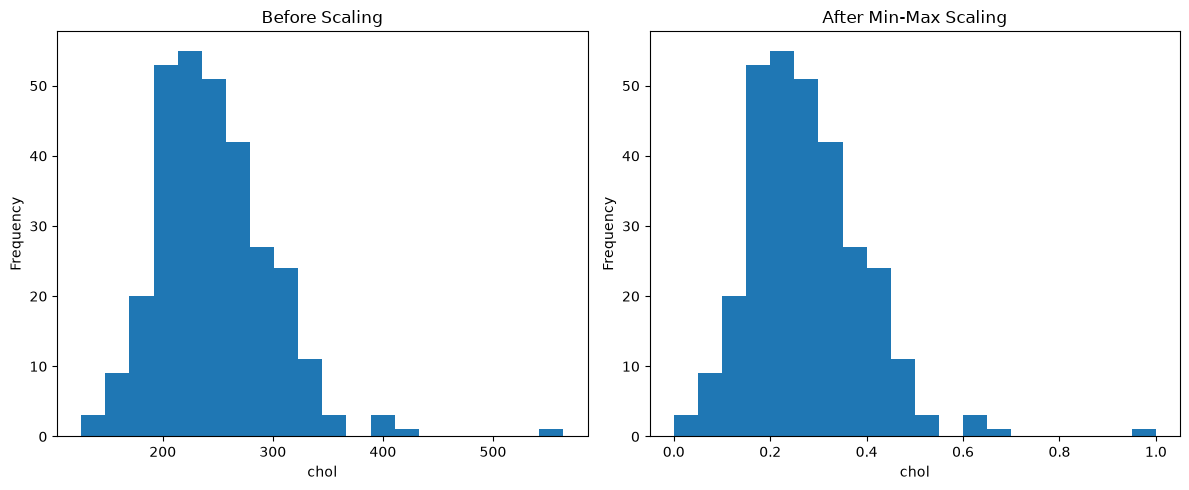

In [88]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(df['chol'], bins=20)
ax[0].set_title("Before Scaling")
ax[0].set_xlabel("chol")
ax[0].set_ylabel("Frequency")

ax[1].hist(df_scaled['chol'], bins=20)
ax[1].set_title("After Min-Max Scaling")
ax[1].set_xlabel("chol")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

فقط مقیاس اعداد را تغییر میدهد نه توزیع داده ها را scailing 

## سوال 40

مقایسه کنید:

* MinMax
* Standardization

برای این پروژه کدام مناسب‌تر است؟

---

bastegi be algoritm entekhabi darad. hardo ghabele estefade ast . chon outlier nadarim va data ro clean kardim pas min-max ham be andazeye standardization monasebe.

# بخش هشتم

# Dataset Validation

---

## سوال 41

شکل نهایی دیتاست را گزارش کنید.

---

In [89]:
# df_standard.describe()
df_standard.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_risk,bp_level,heart_rate_ratio,cardio_risk_score
0,0.952197,1,3,0.763956,-0.256334,1,0,0.015443,0,1.087338,0,0,1,1,Middle Age,Normal,High,2.380952,378
1,-1.915313,1,2,-0.092738,0.072199,0,1,1.633471,0,2.122573,0,0,2,1,Young,High,High,5.054054,380
2,-1.474158,0,1,-0.092738,-0.816773,0,0,0.977514,0,0.310912,2,0,2,1,Young,Normal,High,4.195122,334
3,0.180175,1,1,-0.663867,-0.198357,0,1,1.239897,0,-0.206705,2,0,2,1,Middle Age,Normal,Normal,3.178571,356
4,0.290464,0,0,-0.663867,2.082050,0,1,0.583939,1,-0.379244,2,0,2,1,Middle Age,High,Normal,2.859649,474


## سوال 42

آیا Null باقی مانده است؟

---

null nadashtim aslan 

## سوال 43

آیا Duplicate باقی مانده است؟

---

modiriat shodan 

## سوال 44

آیا Outlier ها مدیریت شده‌اند؟

---

outlier ha hazf shodan

## سوال 45

آیا تمامی ویژگی‌ها فرمت مناسبی دارند؟

---

In [90]:
df_standard.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   age                303 non-null    float64 
 1   sex                303 non-null    int64   
 2   cp                 303 non-null    int64   
 3   trestbps           303 non-null    float64 
 4   chol               303 non-null    float64 
 5   fbs                303 non-null    int64   
 6   restecg            303 non-null    int64   
 7   thalach            303 non-null    float64 
 8   exang              303 non-null    int64   
 9   oldpeak            303 non-null    float64 
 10  slope              303 non-null    int64   
 11  ca                 303 non-null    int64   
 12  thal               303 non-null    int64   
 13  target             303 non-null    int64   
 14  age_group          303 non-null    category
 15  chol_risk          303 non-null    category
 16  bp_level           

## سوال 46

آیا داده برای KNN مناسب است؟

توضیح دهید.

---

monasebe . chon dade adadi ast / dade kochak ast 

## سوال 47

آیا داده برای Logistic Regression مناسب است؟

توضیح دهید.

---

ba tavajoh be standard sazi shode monasebe / chon sotone target binary ast okeye./ rabeteye baazi az sotoon ha peyvaste ast

## سوال 48

آیا داده برای Decision Tree مناسب است؟

توضیح دهید.

---

kolan bedoon standardsazi ham ghabele estefade ast.

## سوال 49

دیتاست نهایی را ذخیره کنید:

```python
heart_prepared.csv
```

---

In [91]:
df_standard.to_csv("heart_prepared.csv")

## سوال 50

یک گزارش مدیریتی تهیه کنید.

به سوالات زیر پاسخ دهید:

1. چه تغییراتی روی داده انجام شد؟
2. چه ویژگی‌هایی حذف شدند؟
3. چه ویژگی‌هایی ساخته شدند؟
4. چه مشکلاتی برطرف شد؟
5. آیا داده برای Modeling آماده است؟

---

# تحویل پروژه

فایل‌های زیر باید ارسال شوند:

```python
task002_data_preparation.ipynb
heart_prepared.csv
```

---

# هدف آموزشی این تسک

پس از پایان این تمرین دانشجو باید بتواند:

✅ Data Selection انجام دهد

✅ Data Cleaning انجام دهد

✅ Feature Construction انجام دهد

✅ Data Integration انجام دهد

✅ Data Formatting انجام دهد

✅ Data Reduction انجام دهد

✅ Scaling و Normalization انجام دهد

✅ یک دیتاست خام را به یک دیتاست آماده مدل‌سازی تبدیل کند

این دقیقاً خروجی مورد انتظار مرحله Data Preparation در فرآیند CRISP-DM است.